# CFReT Morphological Signature Significance Plots

This notebook visualizes the statistical significance and effect size of morphological features obtained from the CFReT dataset. By plotting feature statistics—specifically Kolmogorov-Smirnov (KS) effect size and FDR-corrected p-values—we assess which morphological features significantly distinguish failing from healthy cardiac fibroblasts. We split these visualizations into two panels: one highlighting the specific fluorescent channels, and the other dividing features into "on-morphological signatures" and "off-morphological signatures."

In [6]:
suppressPackageStartupMessages({library(arrow)
library(dplyr)
library(ggplot2)
library(tidyr)
library(viridis)
library(RColorBrewer)
library(patchwork) 
library(ggside)
library(IRdisplay)})

Setting input and output paths

In [7]:
# setting signature stats paths
signatures_stats_path <- file.path("../results/signatures/signature_importance.csv")
shuffle_signatures_stats_path <- file.path("../results/signatures/shuffle_signature_importance.csv")

if (!file.exists(signatures_stats_path)) {
  stop(paste("File not found:", signatures_stats_path))
}
if (!file.exists(shuffle_signatures_stats_path)) {
  stop(paste("File not found:", shuffle_signatures_stats_path))
}

# setting output path for the generated plot
sig_plot_output_dir = file.path("./figures")
if (!dir.exists(sig_plot_output_dir)) {
  dir.create(sig_plot_output_dir, showWarnings = FALSE, recursive = TRUE)
}

## Load the Signature Statistics Data

We load the `signature_importance.csv` file, which contains the metrics required to evaluate feature significance.

In [8]:
# Load both signature stats files and label each by shuffled status
sig_stats_df <- read.csv(signatures_stats_path)
sig_stats_df$data_type <- "Non-shuffled"

shuffle_stats_df <- read.csv(shuffle_signatures_stats_path)
shuffle_stats_df$data_type <- "Shuffled"

# Combine into a single dataframe and set factor order so non-shuffled appears on top
combined_df <- rbind(sig_stats_df, shuffle_stats_df)
combined_df$data_type <- factor(combined_df$data_type, levels = c("Non-shuffled", "Shuffled"))

# Keep channel independent from compartment; use source column when available
if (!("channel" %in% colnames(combined_df))) {
  combined_df$channel <- "no-channel"
}
combined_df$channel <- ifelse(is.na(combined_df$channel) | combined_df$channel == "", "no-channel", combined_df$channel)

head(combined_df)

,feature,p_value,ks_stat,p_value_fdr_corrected,neg_log10_p_value,signature,compartment,channel,data_type
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<fct>
1,Cytoplasm_AreaShape_BoundingBoxMinimum_X,1.281552e-04,0.06355500,1.495524e-04,3.8252067,on,Cytoplasm,no-channel,Non-shuffled
2,Cytoplasm_AreaShape_Compactness,7.846663e-01,0.01883572,7.894728e-01,0.1026628,off,Cytoplasm,no-channel,Non-shuffled
3,Cytoplasm_AreaShape_Eccentricity,3.889191e-47,0.21161789,9.903871e-47,46.0041950,on,Cytoplasm,no-channel,Non-shuffled
4,Cytoplasm_AreaShape_Extent,1.873207e-21,0.14228771,3.139533e-21,20.5031349,on,Cytoplasm,no-channel,Non-shuffled
5,Cytoplasm_AreaShape_FormFactor,7.846663e-01,0.01883572,7.894728e-01,0.1026628,off,Cytoplasm,no-channel,Non-shuffled
6,Cytoplasm_AreaShape_MajorAxisLength,7.015711e-42,0.19945032,1.652087e-41,40.7819672,on,Cytoplasm,no-channel,Non-shuffled


## Visualizing Feature Significance

We generate two side-by-side scatter plots to visualize the significance and effect size of differences between failing and healthy cells:

- **X-axis:** KS statistic (effect size) – quantifies the magnitude of difference between distributions.
- **Y-axis:** -log10(FDR-corrected p-value) – quantifies the statistical significance of that difference.
- **Significance Threshold:** A horizontal dashed line at `-log10(0.05)` marks the boundary. Features above this line are statistically significant.

**Panel 1 - Feature significance by channel:**
Colors each feature according to its imaging channel (e.g., Cells, Cytoplasm, Nuclei). This helps identify if specific compartments or stains are driving the observed phenotypic differences.

**Panel 2 - Feature significance by signature type:**
Colors features based on whether they are classified as an **on-morphological signature** (passing the significance threshold) or an **off-morphological signature** (failing to pass). Off-morphological signatures effectively serve as a metric of control or baseline variation for high-content screening.

Saved: ./figures/cfret_stratified_significance_plots.png 
Saved: ./figures/shuffled_cfret_stratified_significance_plots.png 


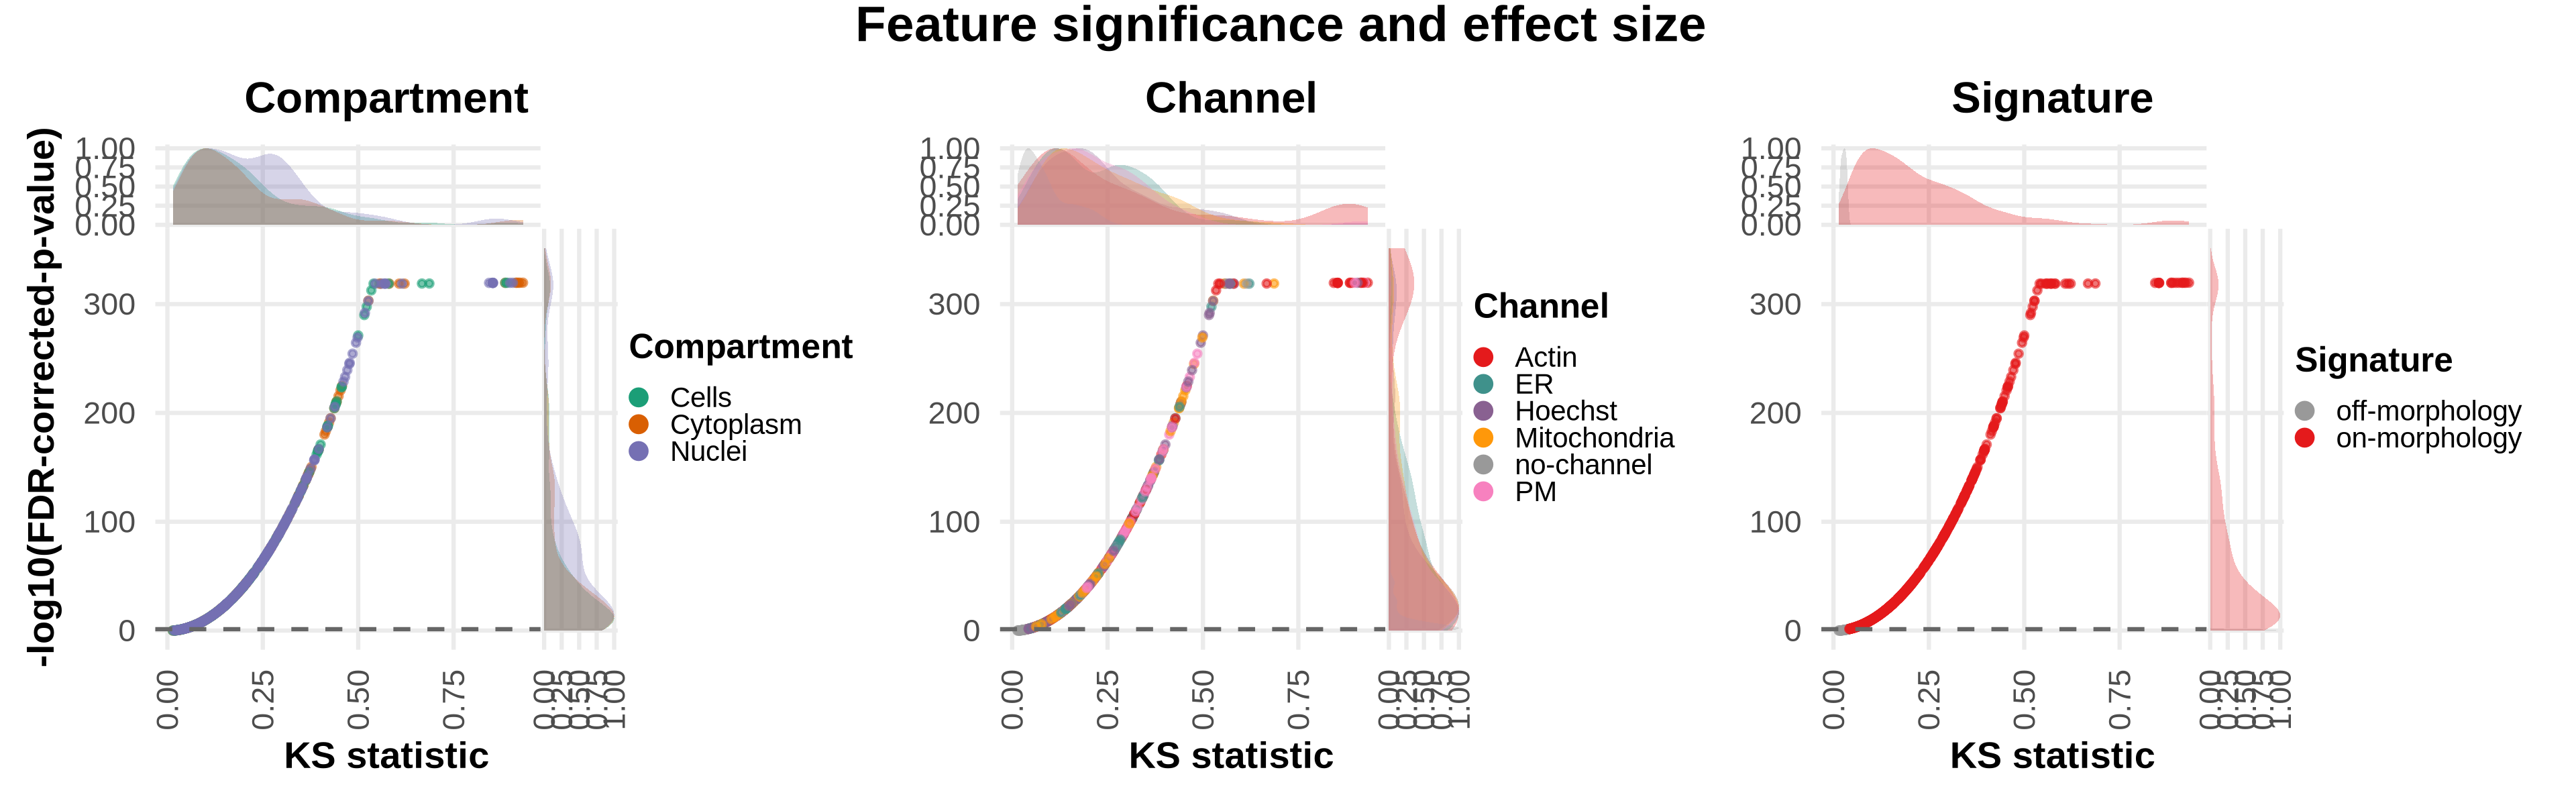

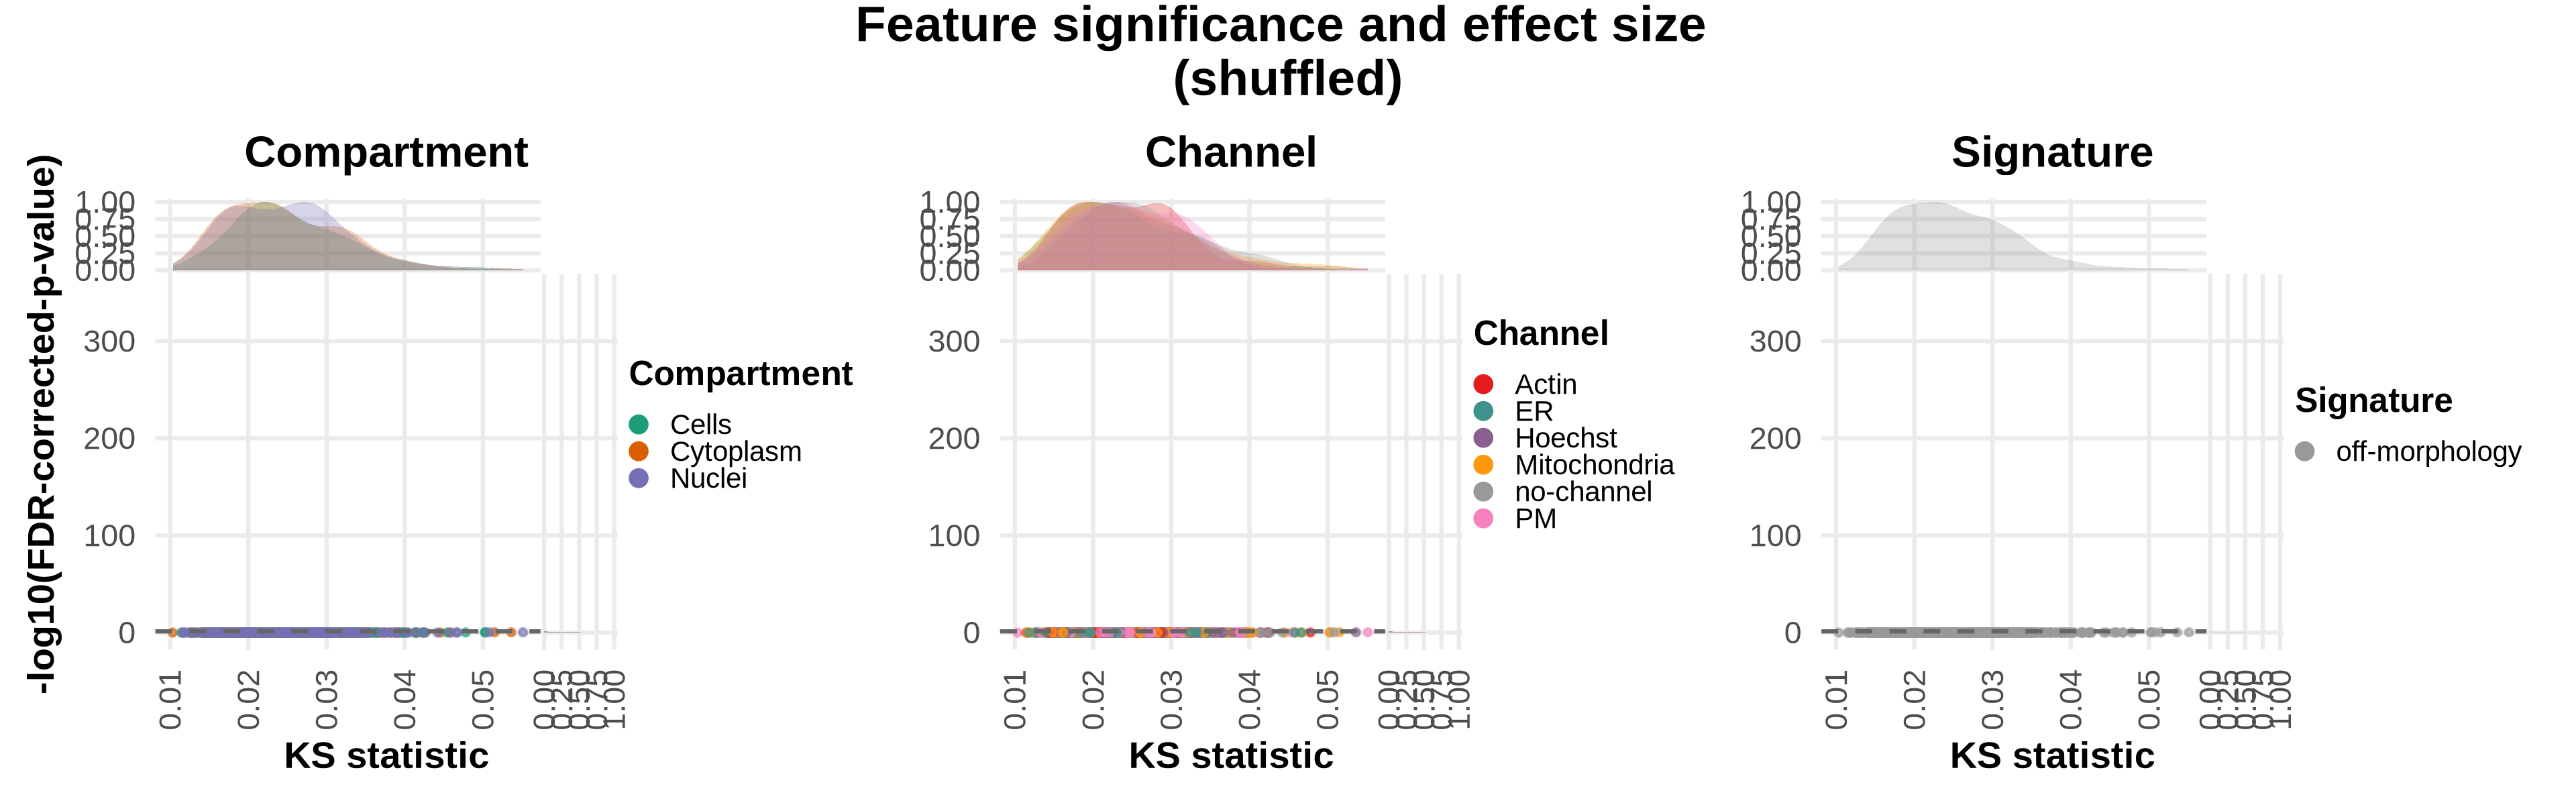

In [9]:
# Configure plot dimensions — enlarged for publication
height <- 10
width <- 32
options(repr.plot.width = width, repr.plot.height = height)

# Generate color palettes for the different stratifications
n_compartments <- length(unique(combined_df$compartment))
compartment_palette <- brewer.pal(max(3, min(n_compartments, 8)), "Dark2")

# Handle channel palette: use a distinct palette for channels, and handle NA/missing
unique_channels <- sort(unique(combined_df$channel))
n_channels <- length(unique_channels)
channel_palette_base <- colorRampPalette(brewer.pal(8, "Set1"))(n_channels)
names(channel_palette_base) <- unique_channels

# Set a shared Y-axis limit across both datasets so plots are directly comparable
y_max <- max(combined_df$neg_log10_p_value[is.finite(combined_df$neg_log10_p_value)], na.rm = TRUE) * 1.1

make_stratified_plots <- function(df, show_yside = TRUE, title_suffix = "") {
  
  # remove infinite values for plotting
  df <- df[is.finite(df$neg_log10_p_value), ]
  
  # Replace NA/empty channels with "no-channel"
  df$channel[is.na(df$channel) | df$channel == ""] <- "no-channel"
  
  # Update palette for this specific dataframe view if "no-channel" exists
  local_channel_palette <- channel_palette_base
  if ("no-channel" %in% df$channel) {
    local_channel_palette["no-channel"] <- "gray60"
  }

  # Add a newline before the suffix to prevent cutoff
  display_suffix <- if(title_suffix != "") paste0("\n", title_suffix) else ""
  
  # Base theme for all panels
  base_theme <- theme_minimal(base_size = 39.2) +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold", size = 39.2, lineheight = 0.8),
      axis.title = element_text(size = 33.6, face = "bold"),
      axis.text = element_text(size = 28),
      axis.text.x = element_text(size = 28, angle = 90, vjust = 0.5, hjust = 1),
      legend.position = "right",
      legend.title = element_text(face = "bold", size = 30.8),
      legend.text = element_text(size = 25.2),
      legend.box.spacing = grid::unit(0.24, "cm"),
      legend.margin = margin(3.3, 3.3, 3.3, 3.3),
      panel.grid.minor = element_blank(),
      ggside.panel.scale = 0.2,
      ggside.panel.spacing = grid::unit(0.12, "cm")
    )

  # Panel 1: Compartments
  p1 <- ggplot(df, aes(x = ks_stat, y = neg_log10_p_value, color = compartment)) +
    geom_point(size = 2, alpha = 0.6) +
    geom_xsidedensity(aes(y = after_stat(ndensity), fill = compartment), alpha = 0.3, color = NA, position = "identity") +
    scale_color_manual(values = compartment_palette) +
    scale_fill_manual(values = compartment_palette, guide = "none") +
    scale_y_continuous(limits = c(0, y_max), oob = scales::squish) +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray40") +
    labs(x = "KS statistic", y = "-log10(FDR-corrected-p-value)", title = "Compartment", color = "Compartment") +
    guides(color = guide_legend(override.aes = list(size = 6, alpha = 1))) +
    base_theme

  # Panel 2: Channels
  p2 <- ggplot(df, aes(x = ks_stat, y = neg_log10_p_value, color = channel)) +
    geom_point(size = 2, alpha = 0.6) +
    geom_xsidedensity(aes(y = after_stat(ndensity), fill = channel), alpha = 0.3, color = NA, position = "identity") +
    scale_color_manual(values = local_channel_palette) +
    scale_fill_manual(values = local_channel_palette, guide = "none") +
    scale_y_continuous(limits = c(0, y_max), oob = scales::squish) +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray40") +
    labs(x = "KS statistic", y = NULL, title = "Channel", color = "Channel") +
    guides(color = guide_legend(override.aes = list(size = 6, alpha = 1))) +
    base_theme

  # Panel 3: Signatures
  p3 <- ggplot(df, aes(x = ks_stat, y = neg_log10_p_value, color = signature)) +
    geom_point(size = 2, alpha = 0.6) +
    geom_xsidedensity(aes(y = after_stat(ndensity), fill = signature), alpha = 0.3, color = NA, position = "identity") +
    scale_color_manual(
      values = c("off" = "gray60", "on" = "#E41A1C"),
      labels = c("off" = "off-morphology", "on" = "on-morphology")
    ) +
    scale_fill_manual(values = c("off" = "gray60", "on" = "#E41A1C"), guide = "none") +
    scale_y_continuous(limits = c(0, y_max), oob = scales::squish) +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray40") +
    labs(x = "KS statistic", y = NULL, title = "Signature", color = "Signature") +
    guides(color = guide_legend(override.aes = list(size = 6, alpha = 1))) +
    base_theme

  if (show_yside) {
    p1 <- p1 + geom_ysidedensity(aes(x = after_stat(ndensity), fill = compartment), alpha = 0.3, color = NA, position = "identity")
    p2 <- p2 + geom_ysidedensity(aes(x = after_stat(ndensity), fill = channel), alpha = 0.3, color = NA, position = "identity")
    p3 <- p3 + geom_ysidedensity(aes(x = after_stat(ndensity), fill = signature), alpha = 0.3, color = NA, position = "identity")
  }

  combined_plot <- (p1 | p2 | p3) + 
    plot_annotation(
      title = paste0("Feature significance and effect size ", display_suffix),
      theme = theme(
        plot.title = element_text(size = 44.8, face = "bold", hjust = 0.5),
        plot.subtitle = element_text(size = 33.6, hjust = 0.5, margin = margin(b = 20))
      )
    )
  
  return(combined_plot)
}

# Non-shuffled plot (with y-side distributions)
non_shuffled_plot <- make_stratified_plots(combined_df[combined_df$data_type == "Non-shuffled", ], show_yside = TRUE)
output_png_path <- file.path(sig_plot_output_dir, "cfret_stratified_significance_plots.png")
ggsave(output_png_path, non_shuffled_plot, width = width, height = height, dpi = 300, bg = "white")

# Shuffled plot (as requested)
shuffled_plot <- make_stratified_plots(combined_df[combined_df$data_type == "Shuffled", ], show_yside = TRUE, title_suffix = "(shuffled)")
shuffled_output_png_path <- file.path(sig_plot_output_dir, "shuffled_cfret_stratified_significance_plots.png")
ggsave(shuffled_output_png_path, shuffled_plot, width = width, height = height, dpi = 300, bg = "white")

cat("Saved:", output_png_path, "\n")
cat("Saved:", shuffled_output_png_path, "\n")

non_shuffled_plot
shuffled_plot

These twin scatter plots illustrate the effect size (KS statistic) and statistical significance (-log10 FDR-corrected p-value) of differences between failing and healthy CFReT cardiac fibroblasts for various morphological features. 

- **Left Panel:** Features are colored by their respective cellular compartment or imaging channel (e.g., Cells, Cytoplasm, Nuclei).
- **Right Panel:** Features are colored by their classification into "on-morphological signatures" (red) or "off-morphological signatures" (grey) based on the FDR significance threshold (dashed horizontal line).

**Interpretation:**
- Features plotted higher and further to the right represent highly significant, large-magnitude morphological differences between healthy and failing cells.
- The separation in the right panel confirms a clear boundary between the active, discriminative "on-morphological signatures" and the unperturbed "off-morphological signatures."
- The "off-morphological signatures" remain below the significance threshold, highlighting their potential utility as stable background controls for high-content screening metrics.